In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
plot_df = pd.read_csv('/seq/epiprod02/etorlait/p16/From_Abhishek/plot_df.csv')
plot_df

,Gene,full_id,expression,Donor,Tissue,log_expr,Age_group
0,MTAP,GTEX-1117F-0226-SM-5GZZ7,6.7020,GTEX-1117F,Adipose - Subcutaneous,2.041480,"(60, 70]"
1,CDKN2A,GTEX-1117F-0226-SM-5GZZ7,1.8730,GTEX-1117F,Adipose - Subcutaneous,1.055357,"(60, 70]"
2,CDKN2B-AS1,GTEX-1117F-0226-SM-5GZZ7,0.3826,GTEX-1117F,Adipose - Subcutaneous,0.323966,"(60, 70]"
3,CDKN2B,GTEX-1117F-0226-SM-5GZZ7,15.9700,GTEX-1117F,Adipose - Subcutaneous,2.831447,"(60, 70]"
4,DMRTA1,GTEX-1117F-0226-SM-5GZZ7,0.3353,GTEX-1117F,Adipose - Subcutaneous,0.289156,"(60, 70]"
...,...,...,...,...,...,...,...
121669,CDKN2B-AS1,GTEX-ZZPU-2726-SM-5NQ8O,0.1166,GTEX-ZZPU,Adipose - Subcutaneous,0.110288,"(40, 50]"
121670,CDKN2B,GTEX-ZZPU-2726-SM-5NQ8O,73.4800,GTEX-ZZPU,Adipose - Subcutaneous,4.310531,"(40, 50]"
121671,DMRTA1,GTEX-ZZPU-2726-SM-5NQ8O,1.7460,GTEX-ZZPU,Adipose - Subcutaneous,1.010145,"(40, 50]"
121672,CDKN2A-p14,GTEX-ZZPU-2726-SM-5NQ8O,0.3000,GTEX-ZZPU,Adipose - Subcutaneous,0.262364,"(40, 50]"


In [3]:
plot_df_subs=plot_df[plot_df["Age_group"].isin(['(20, 30]', '(60, 70]'])]
plot_df_subs2=plot_df_subs[plot_df_subs["Gene"].isin(['MTAP', 'CDKN2A', 'CDKN2A-p16', 'CDKN2A-p14', 'CDKN2B', 'CDKN2B-AS1'])]

In [4]:
geneorder=['MTAP', 'CDKN2A', 'CDKN2A-p16', 'CDKN2A-p14', 'CDKN2B', 'CDKN2B-AS1']
ageorder = ['(20, 30]', '(60, 70]']

plot_df_subs2["Gene"] = pd.Categorical(plot_df_subs2["Gene"], categories=geneorder, ordered=True)
plot_df_subs2["Age_group"] = pd.Categorical(plot_df_subs2["Age_group"], categories=ageorder, ordered=True)


/local/scratch/58031962.1.broad/ipykernel_107578/3464320755.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_subs2["Gene"] = pd.Categorical(plot_df_subs2["Gene"], categories=geneorder, ordered=True)
/local/scratch/58031962.1.broad/ipykernel_107578/3464320755.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_subs2["Age_group"] = pd.Categorical(plot_df_subs2["Age_group"], categories=ageorder, ordered=True)


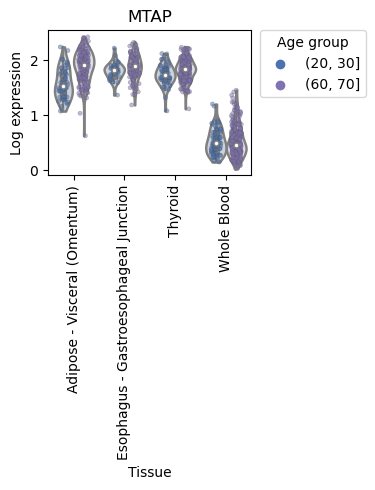

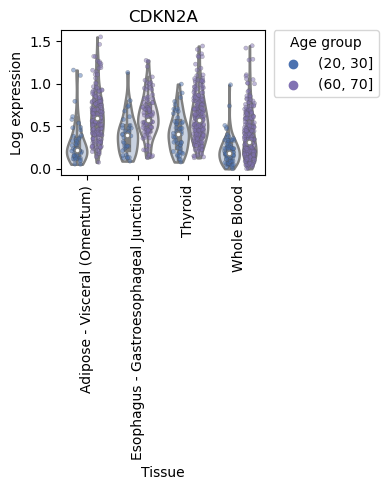

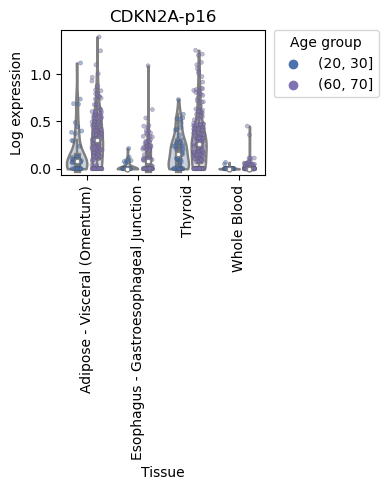

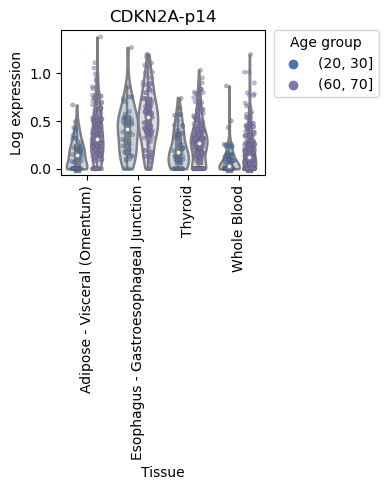

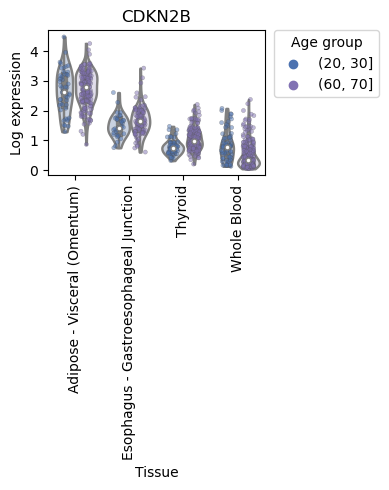

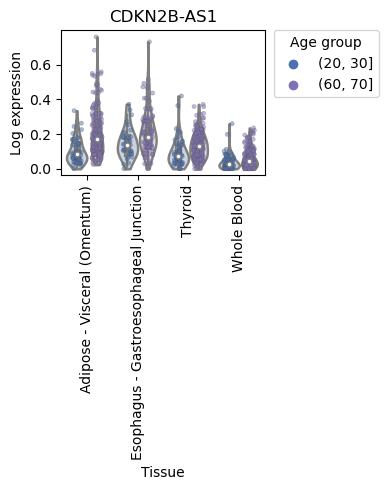

In [5]:
main_tissue = ['Adipose - Visceral (Omentum)',
               'Esophagus - Gastroesophageal Junction',
               'Thyroid',
               'Whole Blood']

plot_df_subs3=plot_df_subs2[plot_df_subs2["Tissue"].isin(main_tissue)].copy()
plot_df_subs3["Tissue"] = plot_df_subs3["Tissue"].astype("category").cat.remove_unused_categories()

mypalette1 = ["#4C72B0", "#8172B3"]
mypalette = {
    "(20, 30]": "#c5d1e5",
    "(60, 70]": "#dfdbec"
}

for this_gene in geneorder:
    nrows, ncols = 1, 1
    fig = plt.figure(figsize=(4, 5))
    ax = fig.add_subplot(1, 1, 1)

    # Subset for this gene
    temp = plot_df_subs3[plot_df_subs3.Gene == this_gene].copy()

    # Stripplot (individual dots)
    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    # Violin plot 
    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # Title/ labels
    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[0:len(ageorder)],
        labels[0:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )

    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_MainT_" + this_gene +'.pdf'), format='pdf')

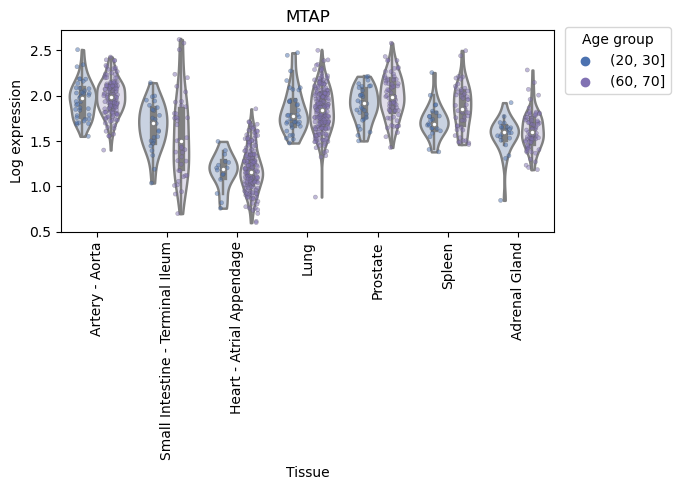

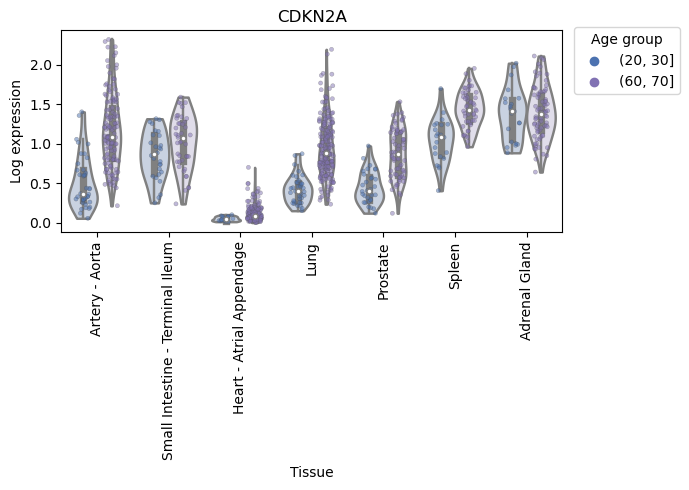

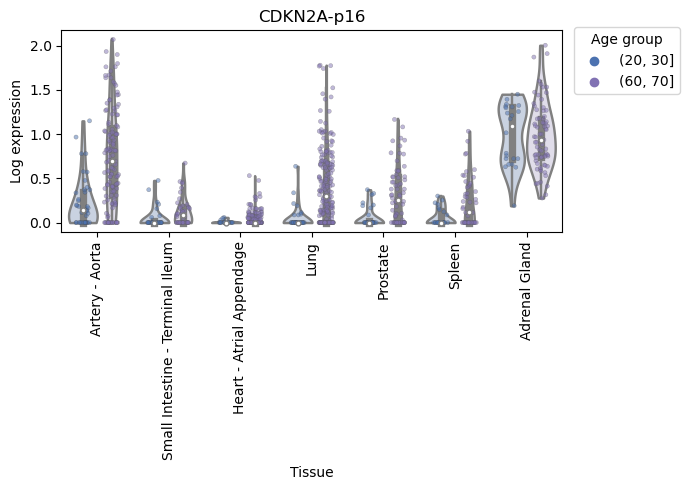

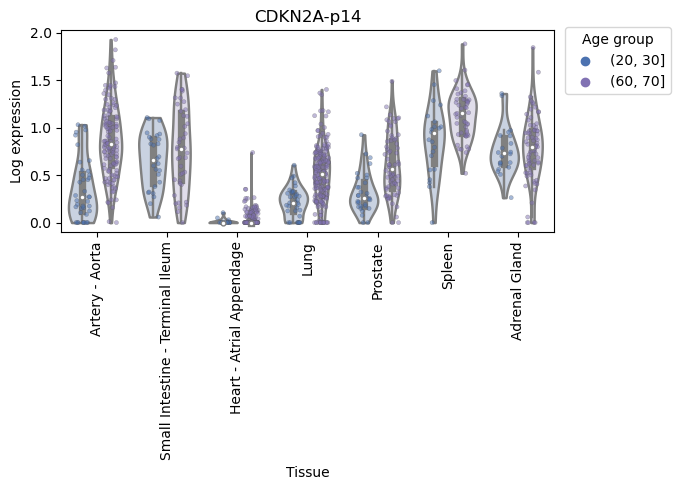

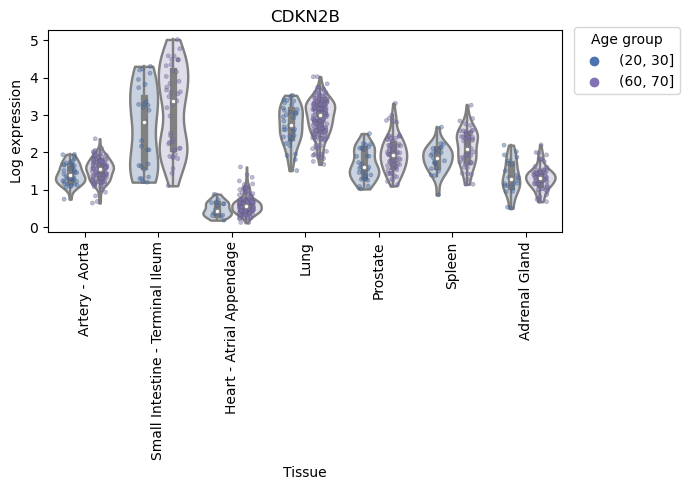

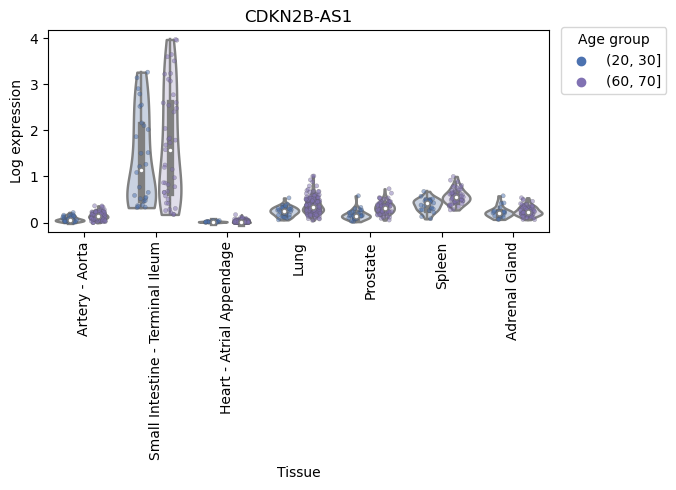

In [6]:
supp_tissue = ['Artery - Aorta',
               'Small Intestine - Terminal Ileum',
               'Heart - Atrial Appendage',
               'Lung',
               'Prostate',
               'Spleen',
               'Adrenal Gland']

plot_df_subs4=plot_df_subs2[plot_df_subs2["Tissue"].isin(supp_tissue)].copy()
plot_df_subs4["Tissue"] = plot_df_subs4["Tissue"].astype("category").cat.remove_unused_categories()

mypalette1 = ["#4C72B0", "#8172B3"]
mypalette = {
    "(20, 30]": "#c5d1e5",
    "(60, 70]": "#dfdbec"
}

for this_gene in geneorder:
    nrows, ncols = 1, 1
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(1, 1, 1)

    # Subset for this gene
    temp = plot_df_subs4[plot_df_subs4.Gene == this_gene].copy()

    # Stripplot (individual dots)
    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    # Violin plot 
    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # Title/ labels
    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[0:len(ageorder)],
        labels[0:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )

    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_SuppT_" + this_gene +'.pdf'), format='pdf')

In [7]:
temp

,Gene,full_id,expression,Donor,Tissue,log_expr,Age_group
30,CDKN2B-AS1,GTEX-1117F-0726-SM-5GIEN,0.09348,GTEX-1117F,Heart - Atrial Appendage,0.089365,"(60, 70]"
254,CDKN2B-AS1,GTEX-111FC-0626-SM-5N9CU,0.00000,GTEX-111FC,Heart - Atrial Appendage,0.000000,"(60, 70]"
275,CDKN2B-AS1,GTEX-111FC-1126-SM-5GZWU,0.29870,GTEX-111FC,Lung,0.261364,"(60, 70]"
282,CDKN2B-AS1,GTEX-111FC-1326-SM-5N9D9,1.24200,GTEX-111FC,Spleen,0.807368,"(60, 70]"
296,CDKN2B-AS1,GTEX-111FC-2026-SM-5GZYO,0.43420,GTEX-111FC,Prostate,0.360607,"(60, 70]"
...,...,...,...,...,...,...,...
121214,CDKN2B-AS1,GTEX-ZYW4-1526-SM-5SIBA,0.22620,GTEX-ZYW4,Lung,0.203920,"(60, 70]"
121277,CDKN2B-AS1,GTEX-ZYY3-0926-SM-5E454,0.17450,GTEX-ZYY3,Lung,0.160843,"(60, 70]"
121284,CDKN2B-AS1,GTEX-ZYY3-1226-SM-5EQKM,0.07451,GTEX-ZYY3,Artery - Aorta,0.071865,"(60, 70]"
121396,CDKN2B-AS1,GTEX-ZZ64-0526-SM-5GZXM,22.13000,GTEX-ZZ64,Small Intestine - Terminal Ileum,3.141130,"(20, 30]"


In [8]:
temp.groupby("Age_group")["Donor"].nunique()

Age_group
(20, 30]     77
(60, 70]    272
Name: Donor, dtype: int64

In [9]:
tissues_of_interest = ['Adipose - Visceral (Omentum)', 
                       'Artery - Aorta',
                       'Small Intestine - Terminal Ileum', 
                       'Esophagus - Gastroesophageal Junction', 
                       'Heart - Atrial Appendage',
                       'Lung', 
                      'Prostate', 
                      'Spleen', 
                      'Thyroid', 
                      'Whole Blood', 
                      'Adrenal Gland']



In [10]:
from scipy import stats
pd.reset_option('display.float_format')

### first tissue: Adipose - Visceral (Omentum) 
tissue='Adipose - Visceral (Omentum)'
print(tissue)
results = []

for gene, subset in plot_df_subs2[plot_df_subs2.Tissue == 'Adipose - Visceral (Omentum)'].groupby("Gene"):
    group1 = subset.loc[subset["Age_group"] == "(20, 30]", "log_expr"]
    group2 = subset.loc[subset["Age_group"] == "(60, 70]", "log_expr"]
    

    t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
    
    results.append({
        "gene name": gene,
        "p_value": p_val,
        "mean_20-30": group1.mean(),
        "mean_60-70": group2.mean(),
        "n_20-30": len(group1),
        "n_60-70": len(group2),

    })

print ("")
print ("n of (20, 30]", len(group1))
print ("n of (60, 70]",  len(group2))
print ("")

results_df = pd.DataFrame(results)
results_df.insert(0, "tissue", tissue)

print(results_df)


Adipose - Visceral (Omentum)

n of (20, 30] 49
n of (60, 70] 169

                         tissue   gene name       p_value  mean_20-30  \
0  Adipose - Visceral (Omentum)        MTAP  4.818967e-09    1.587531   
1  Adipose - Visceral (Omentum)      CDKN2A  3.666113e-13    0.298196   
2  Adipose - Visceral (Omentum)  CDKN2A-p16  3.365277e-05    0.162655   
3  Adipose - Visceral (Omentum)  CDKN2A-p14  3.140264e-10    0.149120   
4  Adipose - Visceral (Omentum)      CDKN2B  5.506797e-01    2.660786   
5  Adipose - Visceral (Omentum)  CDKN2B-AS1  1.360674e-11    0.100598   

   mean_60-70  n_20-30  n_60-70  
0    1.886466       49      169  
1    0.634943       49      169  
2    0.337626       49      169  
3    0.358148       49      169  
4    2.727959       49      169  
5    0.207984       49      169  


In [11]:
len(group1)

49

In [12]:
tissues_of_interest = ['Artery - Aorta',
                       'Small Intestine - Terminal Ileum', 
                       'Esophagus - Gastroesophageal Junction', 
                       'Heart - Atrial Appendage',
                       'Lung', 
                      'Prostate', 
                      'Spleen', 
                      'Thyroid', 
                      'Whole Blood', 
                      'Adrenal Gland']

### Loop to go through the rest of the tissues

for this_tissue in tissues_of_interest:

    print(this_tissue)
    results = []

    for gene, subset in plot_df_subs2[plot_df_subs2.Tissue == this_tissue].copy().groupby("Gene"):
        group1 = subset.loc[subset["Age_group"] == "(20, 30]", "log_expr"]
        group2 = subset.loc[subset["Age_group"] == "(60, 70]", "log_expr"]
    

        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch’s t-test
    
        results.append({
            "gene name": gene,
            "p_value": p_val,
            "mean_20-30": group1.mean(),
            "mean_60-70": group2.mean(),
            "n_20-30": len(group1),
            "n_60-70": len(group2),

        })

    print ("")
    print ("n of (20, 30]", len(group1))
    print ("n of (60, 70]",  len(group2))
    print ("")

    results_df_temp = pd.DataFrame(results)
    results_df_temp.insert(0, "tissue", this_tissue)

    results_df = pd.concat([results_df, results_df_temp])

    print(results_df)

Artery - Aorta

n of (20, 30] 40
n of (60, 70] 131

                         tissue   gene name       p_value  mean_20-30  \
0  Adipose - Visceral (Omentum)        MTAP  4.818967e-09    1.587531   
1  Adipose - Visceral (Omentum)      CDKN2A  3.666113e-13    0.298196   
2  Adipose - Visceral (Omentum)  CDKN2A-p16  3.365277e-05    0.162655   
3  Adipose - Visceral (Omentum)  CDKN2A-p14  3.140264e-10    0.149120   
4  Adipose - Visceral (Omentum)      CDKN2B  5.506797e-01    2.660786   
5  Adipose - Visceral (Omentum)  CDKN2B-AS1  1.360674e-11    0.100598   
0                Artery - Aorta        MTAP  4.526422e-01    1.958552   
1                Artery - Aorta      CDKN2A  2.493575e-16    0.506675   
2                Artery - Aorta  CDKN2A-p16  2.220676e-12    0.231399   
3                Artery - Aorta  CDKN2A-p14  1.440403e-12    0.352406   
4                Artery - Aorta      CDKN2B  4.166791e-02    1.426415   
5                Artery - Aorta  CDKN2B-AS1  8.365624e-09    0.075461   

In [13]:
results_df

,tissue,gene name,p_value,mean_20-30,mean_60-70,n_20-30,n_60-70
0,Adipose - Visceral (Omentum),MTAP,4.818967e-09,1.587531,1.886466,49,169
1,Adipose - Visceral (Omentum),CDKN2A,3.666113e-13,0.298196,0.634943,49,169
2,Adipose - Visceral (Omentum),CDKN2A-p16,3.365277e-05,0.162655,0.337626,49,169
3,Adipose - Visceral (Omentum),CDKN2A-p14,3.140264e-10,0.149120,0.358148,49,169
4,Adipose - Visceral (Omentum),CDKN2B,5.506797e-01,2.660786,2.727959,49,169
...,...,...,...,...,...,...,...
1,Adrenal Gland,CDKN2A,8.788792e-01,1.378228,1.390497,22,76
2,Adrenal Gland,CDKN2A-p16,8.982850e-01,0.990527,0.979521,22,76
3,Adrenal Gland,CDKN2A-p14,7.781055e-01,0.756332,0.775340,22,76
4,Adrenal Gland,CDKN2B,7.152391e-01,1.349492,1.311933,22,76


In [14]:
from statsmodels.stats.multitest import multipletests

results_df["p_adj_fdr_bh"] = multipletests(results_df["p_value"], method="fdr_bh")[1]
results_df["p_adj_fdr_bh_float"] = results_df["p_adj_fdr_bh"].map(lambda x: f"{x:.6f}")
results_df["p_adj_fdr_bh_significant"] = results_df["p_adj_fdr_bh"]<0.05

results_df["p_adj_bonferroni"] = multipletests(results_df["p_value"], method="bonferroni")[1]
results_df["p_adj_bonferroni_float"] = results_df["p_adj_bonferroni"].map(lambda x: f"{x:.6f}")
results_df["p_adj_bonferroni_significant"] = results_df["p_adj_bonferroni"]<0.05


print(results_df)

                          tissue   gene name       p_value  mean_20-30  \
0   Adipose - Visceral (Omentum)        MTAP  4.818967e-09    1.587531   
1   Adipose - Visceral (Omentum)      CDKN2A  3.666113e-13    0.298196   
2   Adipose - Visceral (Omentum)  CDKN2A-p16  3.365277e-05    0.162655   
3   Adipose - Visceral (Omentum)  CDKN2A-p14  3.140264e-10    0.149120   
4   Adipose - Visceral (Omentum)      CDKN2B  5.506797e-01    2.660786   
..                           ...         ...           ...         ...   
1                  Adrenal Gland      CDKN2A  8.788792e-01    1.378228   
2                  Adrenal Gland  CDKN2A-p16  8.982850e-01    0.990527   
3                  Adrenal Gland  CDKN2A-p14  7.781055e-01    0.756332   
4                  Adrenal Gland      CDKN2B  7.152391e-01    1.349492   
5                  Adrenal Gland  CDKN2B-AS1  4.872788e-01    0.229120   

    mean_60-70  n_20-30  n_60-70  p_adj_fdr_bh p_adj_fdr_bh_float  \
0     1.886466       49      169  2.607519

In [15]:
results_df

,tissue,gene name,p_value,mean_20-30,mean_60-70,n_20-30,n_60-70,p_adj_fdr_bh,p_adj_fdr_bh_float,p_adj_fdr_bh_significant,p_adj_bonferroni,p_adj_bonferroni_float,p_adj_bonferroni_significant
0,Adipose - Visceral (Omentum),MTAP,4.818967e-09,1.587531,1.886466,49,169,2.607519e-08,0.000000,True,3.180518e-07,0.000000,True
1,Adipose - Visceral (Omentum),CDKN2A,3.666113e-13,0.298196,0.634943,49,169,4.839269e-12,0.000000,True,2.419634e-11,0.000000,True
2,Adipose - Visceral (Omentum),CDKN2A-p16,3.365277e-05,0.162655,0.337626,49,169,7.998660e-05,0.000080,True,2.221083e-03,0.002221,True
3,Adipose - Visceral (Omentum),CDKN2A-p14,3.140264e-10,0.149120,0.358148,49,169,2.072574e-09,0.000000,True,2.072574e-08,0.000000,True
4,Adipose - Visceral (Omentum),CDKN2B,5.506797e-01,2.660786,2.727959,49,169,6.160146e-01,0.616015,False,1.000000e+00,1.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,Adrenal Gland,CDKN2A,8.788792e-01,1.378228,1.390497,22,76,9.063442e-01,0.906344,False,1.000000e+00,1.000000,False
2,Adrenal Gland,CDKN2A-p16,8.982850e-01,0.990527,0.979521,22,76,9.121047e-01,0.912105,False,1.000000e+00,1.000000,False
3,Adrenal Gland,CDKN2A-p14,7.781055e-01,0.756332,0.775340,22,76,8.283058e-01,0.828306,False,1.000000e+00,1.000000,False
4,Adrenal Gland,CDKN2B,7.152391e-01,1.349492,1.311933,22,76,7.738652e-01,0.773865,False,1.000000e+00,1.000000,False


In [16]:
results_df.p_adj_fdr_bh_significant.value_counts()

True     42
False    24
Name: p_adj_fdr_bh_significant, dtype: int64

In [17]:
results_df.p_adj_bonferroni_significant.value_counts()

False    37
True     29
Name: p_adj_bonferroni_significant, dtype: int64

In [18]:
#results_df.to_csv(os.path.join('plots', "viostripplot_2groups_GTEx_pvals.txt"), sep='\t')

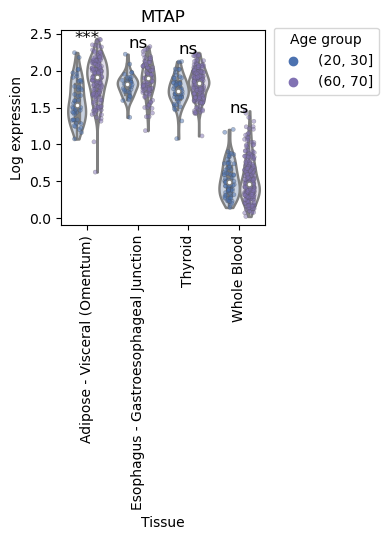

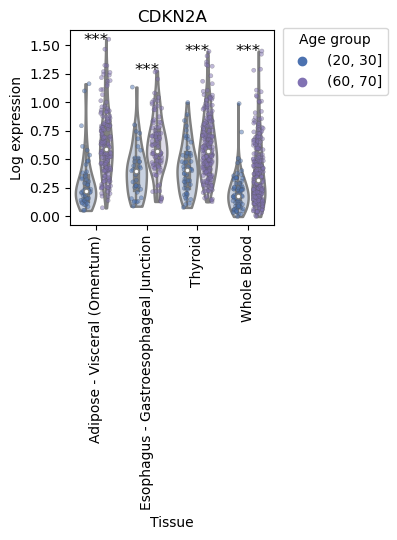

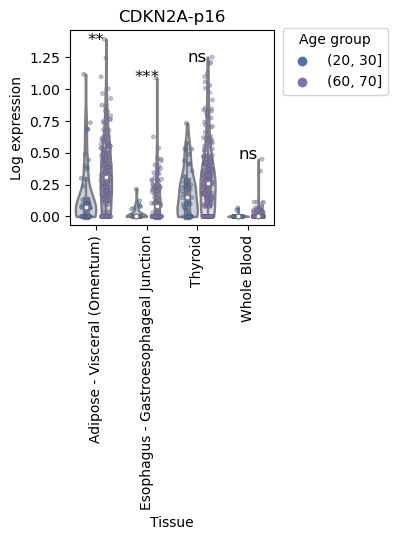

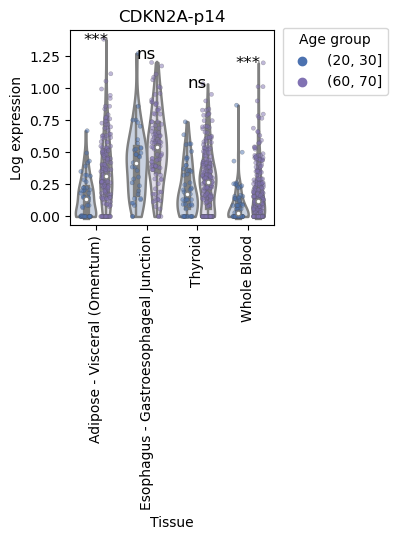

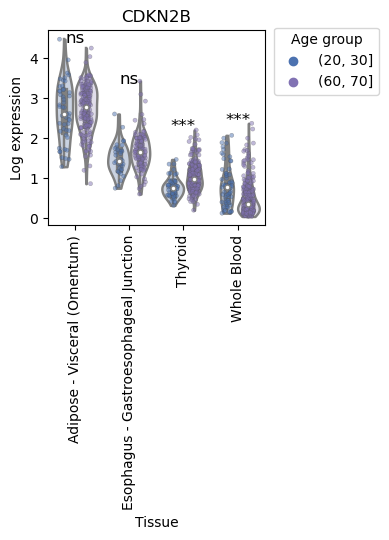

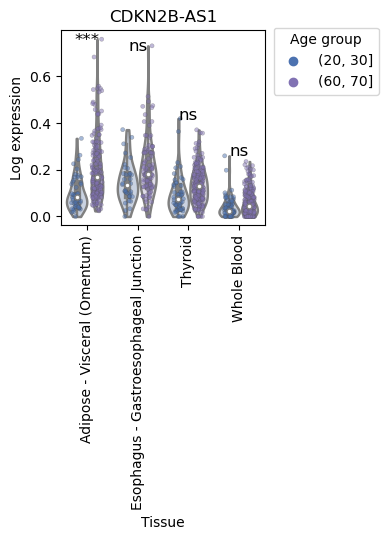

In [19]:
for this_gene in geneorder:
    nrows, ncols = 1, 1
    fig = plt.figure(figsize=(4, 5.5))
    ax = fig.add_subplot(1, 1, 1)

    temp = plot_df_subs3[plot_df_subs3.Gene == this_gene].copy()

    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=main_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # 
    for tissue in main_tissue:
        temp_tissue = temp[temp["Tissue"] == tissue]
        row = results_df[
            (results_df["gene name"] == this_gene) &
            (results_df["tissue"] == tissue)
        ]

        pval = row["p_adj_bonferroni"].values[0]
        # Convert p-value to stars
        if pval < 0.001:
            star = "***"
        elif pval < 0.01:
            star = "**"
        elif pval < 0.05:
            star = "*"
        else:
            star = "ns"

        # x position = tissue index
        xpos = main_tissue.index(tissue)

        # Place the star slightly below the maximum value
        ymax = temp_tissue["log_expr"].max()
        ymin = temp_tissue["log_expr"].min()
        offset = 0.05 * (ymax - ymin)  # 5% of the range
        y_pos = ymax - offset  # inside the box

        ax.text(xpos, y_pos, star, ha="center", va="bottom", fontsize=12, color="black")

    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(ageorder)],
        labels[:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )
    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_MainT_" + this_gene +'_withStars.pdf'), format='pdf')


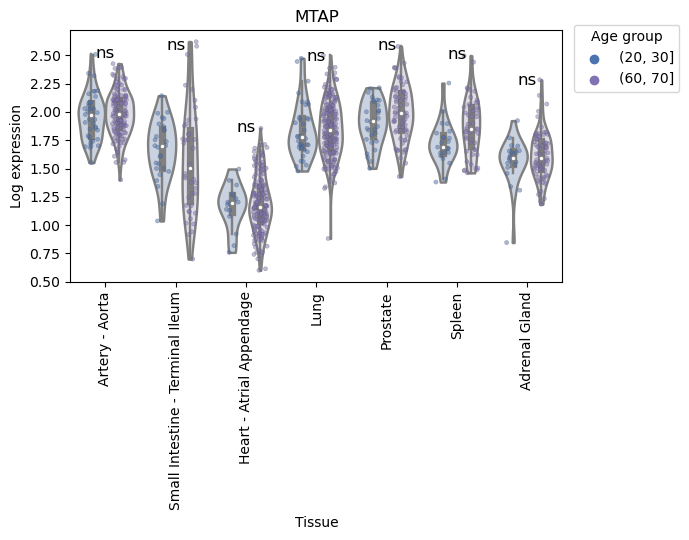

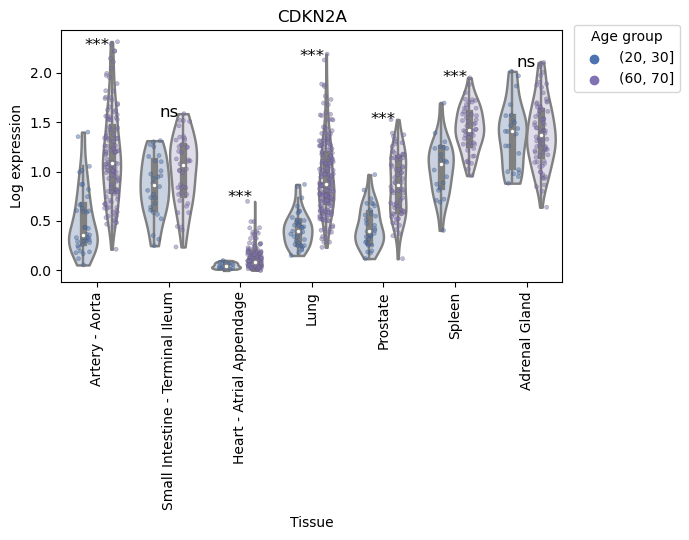

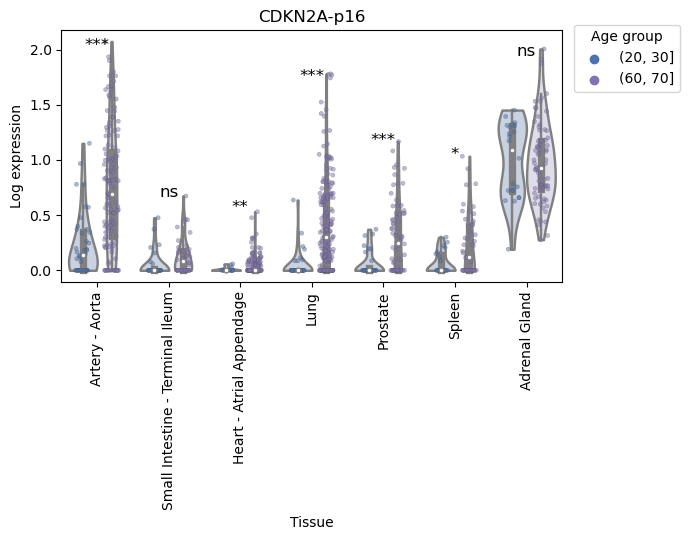

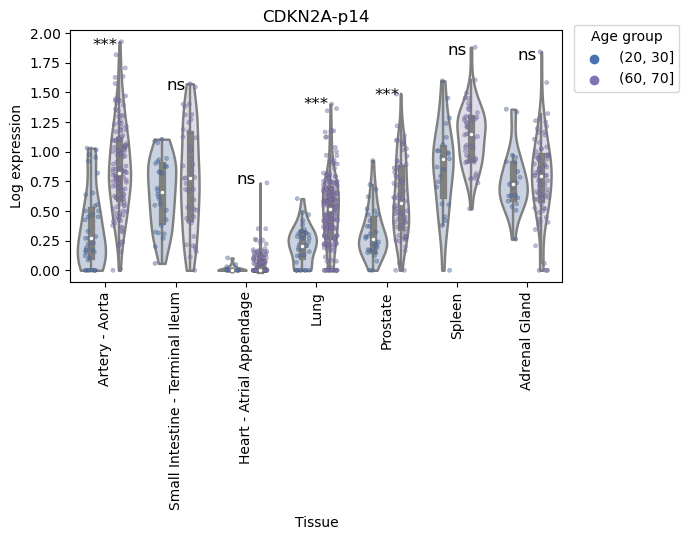

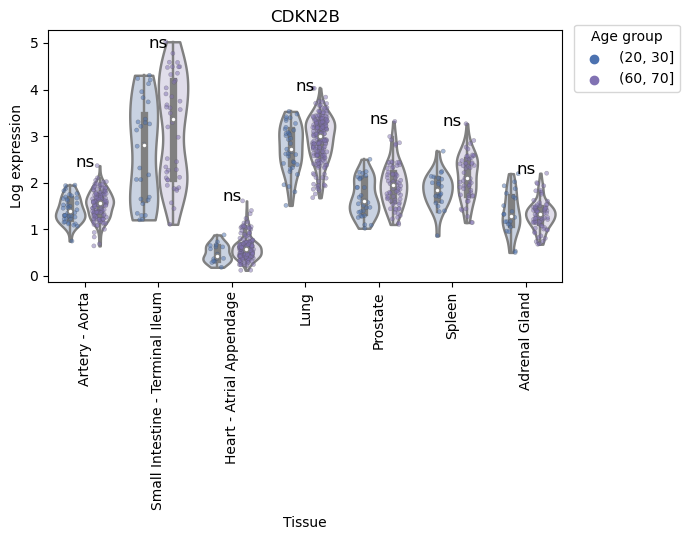

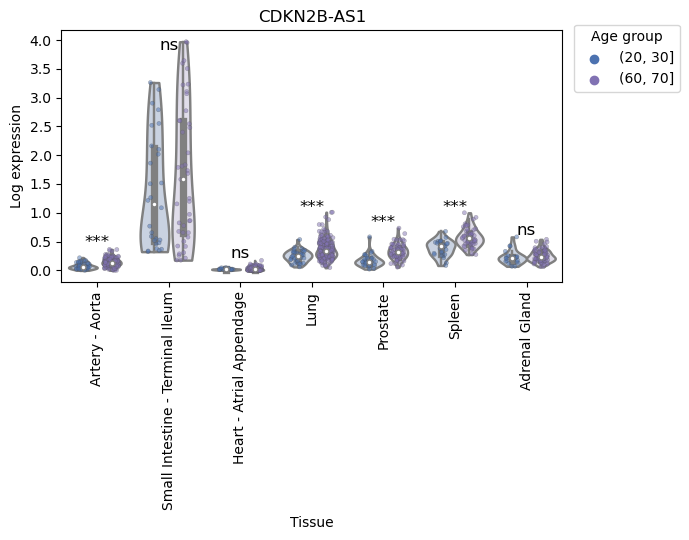

In [20]:
for this_gene in geneorder:
    nrows, ncols = 1, 1
    fig = plt.figure(figsize=(7, 5.5))
    ax = fig.add_subplot(1, 1, 1)
    
    temp = plot_df_subs4[plot_df_subs4.Gene == this_gene].copy()

    sns.stripplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette1,
        jitter=0.2, size=3, dodge=True, alpha=0.5, linewidth=0.3,
        edgecolor="gray", ax=ax
    )

    sns.violinplot(
        x="Tissue", y="log_expr", hue="Age_group", data=temp,
        order=supp_tissue, hue_order=ageorder, palette=mypalette,
        dodge=True, cut=0, linewidth=1.75, alpha=0.01, ax=ax
    )

    # 
    for tissue in supp_tissue:
        temp_tissue = temp[temp["Tissue"] == tissue]
        row = results_df[
            (results_df["gene name"] == this_gene) &
            (results_df["tissue"] == tissue)
        ]

        pval = row["p_adj_bonferroni"].values[0]
        # Convert p-value to stars
        if pval < 0.001:
            star = "***"
        elif pval < 0.01:
            star = "**"
        elif pval < 0.05:
            star = "*"
        else:
            star = "ns"

        # x position = tissue index
        xpos = supp_tissue.index(tissue)

        # Place the star slightly below the maximum value
        ymax = temp_tissue["log_expr"].max()
        ymin = temp_tissue["log_expr"].min()
        offset = 0.05 * (ymax - ymin)  # 5% of the range
        y_pos = ymax - offset  # inside the box

        ax.text(xpos, y_pos, star, ha="center", va="bottom", fontsize=12, color="black")

    ax.set_title(this_gene)
    ax.set_ylabel("Log expression")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(ageorder)],
        labels[:len(ageorder)],
        title="Age group",
        bbox_to_anchor=(1.01, 1.05),
        loc="upper left"
    )
    fig.tight_layout()
    plt.show()
    #fig.savefig(os.path.join('plots', "viostripplot_2groups_SuppT_" + this_gene +'_withStars.pdf'), format='pdf')


In [21]:
import statsmodels
statsmodels.__version__

'0.13.5'

In [22]:
import scipy
scipy.__version__

'1.10.0'

In [23]:
sns.__version__

'0.12.2'